### Astrostatistics lecture 13

original data shape: (1797, 64)


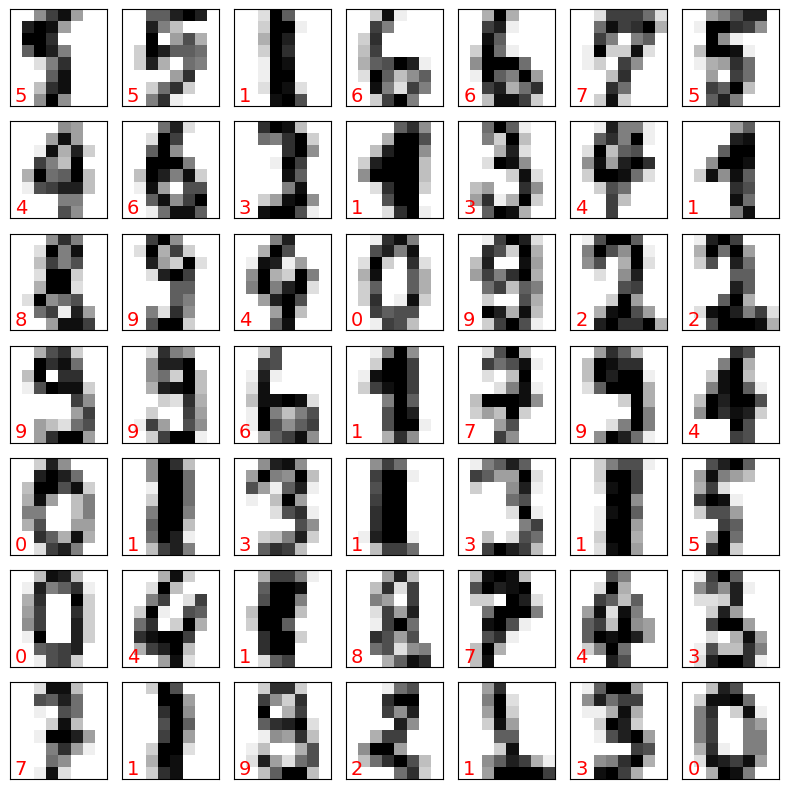

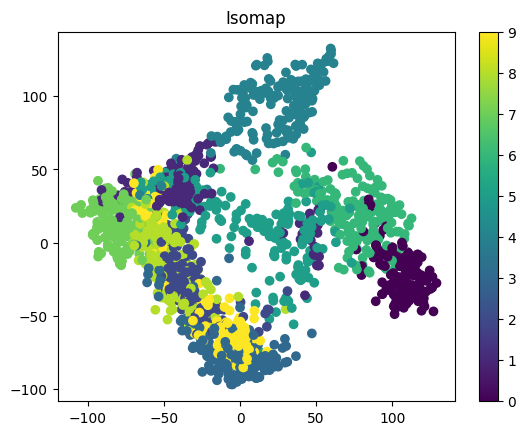

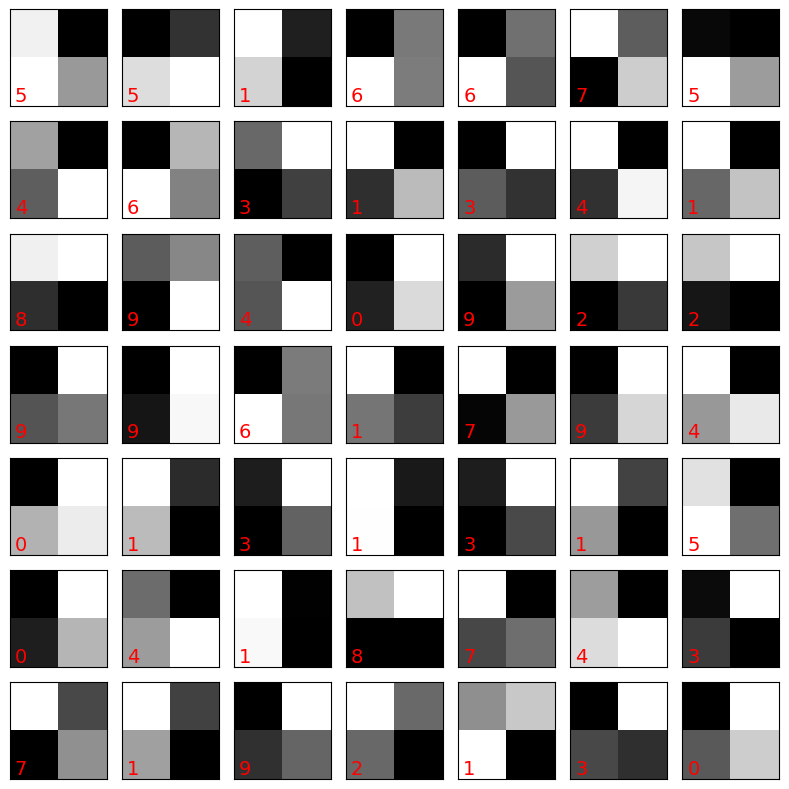

New data shape: (1797, 2, 2)


In [58]:
import matplotlib.pyplot as plt
from matplotlib import offsetbox
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn import datasets
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

digits = datasets.load_digits()     #load the digits dataset

digits_plot = np.random.choice(digits.images.shape[0], size=49)     #pick 49 random ones to visualize
print('original data shape:', digits.data.shape)

#visualize the picked images

fig, ax = plt.subplots(7, 7, figsize=(8, 8))
for i, axi in enumerate(ax.flat):
    axi.imshow(digits.images[digits_plot[i]], cmap='binary')
    axi.set(xticks=[], yticks=[])
    axi.text(0.05, 0.05, str(digits.target[digits_plot[i]]), transform=axi.transAxes, fontsize=14, color='red')
plt.tight_layout()
plt.show()

red_size = 2

embedding = Isomap(n_components=red_size**2, n_neighbors=10)

digits_transformed = embedding.fit_transform(digits.data)   


plt.scatter(digits_transformed[:, 0], digits_transformed[:, 1], c=digits.target, cmap='viridis')
plt.title('Isomap')
plt.colorbar()
plt.show()

#for the indeces we picked we can see how they were transformed

fig, ax = plt.subplots(7, 7, figsize=(8, 8))
for i, axi in enumerate(ax.flat):
    digits_transformed = digits_transformed.reshape(-1, red_size, red_size)
    axi.imshow(digits_transformed[digits_plot[i]], cmap='binary')
    axi.set(xticks=[], yticks=[])
    axi.text(0.05, 0.05, str(digits.target[digits_plot[i]]), transform=axi.transAxes, fontsize=14, color='red')
plt.tight_layout()
plt.show()

print('New data shape:', digits_transformed.shape)


In [ ]:
#divide the dataset into training and testing parts on the original data

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)

#using logistic regression we train our model and check the score

model = LogisticRegression(solver='sag', max_iter=1000)
model.fit(X_train, y_train)

#score on the training set and set test

print('Training set score: %f' % model.score(X_train, y_train))
print('Confusion matrix:\n%s' % confusion_matrix(y_train, model.predict(X_train)))

#now we can just see the confusion matrix

y_pred = model.predict(X_test)
print('\nTest set score: %f' % model.score(X_test, y_test))
print('Confusion matrix:\n%s' % confusion_matrix(y_test, y_pred))

Training set score: 1.000000
Confusion matrix:
[[145   0   0   0   0   0   0   0   0   0]
 [  0 154   0   0   0   0   0   0   0   0]
 [  0   0 144   0   0   0   0   0   0   0]
 [  0   0   0 149   0   0   0   0   0   0]
 [  0   0   0   0 135   0   0   0   0   0]
 [  0   0   0   0   0 135   0   0   0   0]
 [  0   0   0   0   0   0 146   0   0   0]
 [  0   0   0   0   0   0   0 145   0   0]
 [  0   0   0   0   0   0   0   0 144   0]
 [  0   0   0   0   0   0   0   0   0 140]]

Test set score: 0.975000
Confusion matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]


Results for reduced data with 1 dimensions
Training set score: 0.455115
Confusion matrix:
[[133   0   0   0   0   0  12   0   0   0]
 [  0  61   0   3  13   0   9  11  55   2]
 [  0  79   0  14   5   0   0   0  45   1]
 [  0  29   0  66  23  18   0   2   8   3]
 [  0   1   0  20  77  14  17   1   3   2]
 [  0  20   0  17  56   9  10   3  19   1]
 [ 34   0   0   1  16   1  94   0   0   0]
 [  0   0   0   0   0   0   0 132  13   0]
 [  0  43   0   3   1   1   0  15  80   1]
 [  0  25   0  75   1   8   0   9  20   2]]

Test set score: 0.455556
Confusion matrix:
[[31  0  0  0  0  0  2  0  0  0]
 [ 0 16  0  0  2  1  2  2  5  0]
 [ 0 15  0  3  0  1  0  0 14  0]
 [ 0  8  0 16  2  7  0  0  1  0]
 [ 0  0  0 14 25  4  3  0  0  0]
 [ 0  8  0  4 20  3  5  1  6  0]
 [11  0  0  0  1  0 23  0  0  0]
 [ 0  0  0  0  0  0  0 30  4  0]
 [ 0  6  0  0  0  0  0  4 20  0]
 [ 0  6  0 24  1  2  0  3  4  0]]
Results for reduced data with 2 dimensions
Training set score: 0.942937
Confusion matrix:
[[145   0   0 

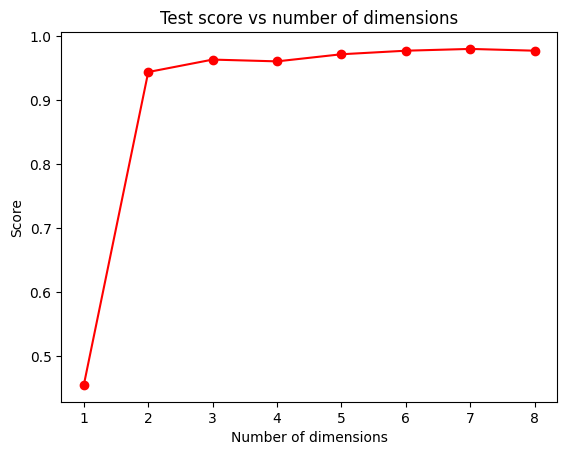

In [69]:
#same thing as before just with the reduced data with dimensions from 8 to lower
score_array=[]
dim=np.arange(1,9)
for i in range(1,9):
    red_size = i

    embedding = Isomap(n_components=red_size**2, n_neighbors=10)

    digits_transformed = embedding.fit_transform(digits.data)   

    X_train, X_test, y_train, y_test = train_test_split(digits_transformed, digits.target, test_size=0.2, random_state=42)

    model = LogisticRegression(solver='sag', max_iter=10000)
    model.fit(X_train, y_train)

    #score on the training set and set test
    print('Results for reduced data with %d dimensions' % red_size)

    print('Training set score: %f' % model.score(X_train, y_train))
    print('Confusion matrix:\n%s' % confusion_matrix(y_train, model.predict(X_train)))

    #now we can just see the confusion matrix

    y_pred = model.predict(X_test)
    print('\nTest set score: %f' % model.score(X_test, y_test))
    print('Confusion matrix:\n%s' % confusion_matrix(y_test, y_pred))
    score_array.append(model.score(X_test, y_test))

plt.plot(dim, score_array, marker='o', color='red')
plt.title('Test score vs number of dimensions')
plt.xlabel('Number of dimensions')
plt.ylabel('Score')
plt.show()